In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sklearn

In [ ]:
train = pd.read_csv("train.csv")

In [ ]:
train["Age"].fillna("unknown")

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,unknown
889,26.0


In [ ]:
train["Cabin"].fillna("unknown")

,Cabin
0,unknown
1,C85
2,unknown
3,C123
4,unknown
...,...
886,unknown
887,B42
888,unknown
889,C148


In [ ]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

In [ ]:
def categorize_age(age):
    if age < 13:
        return 'child'
    elif age < 19:
        return 'teen'
    elif age < 60:
        return 'adult'
    elif age >= 60:
        return 'senior'
    else:
        return 'unknown'

train['AgeGroup'] = train['Age'].apply(categorize_age)

In [ ]:
mean_age = train['Age'].mean()
print("Mean of column Age:", mean_age)

median_age = train['Age'].median()
print("Median of column Age:", median_age)

standard_deviation_age = train['Age'].std()
print("Standard Deviation of column Age:", standard_deviation_age)

Mean of column Age: 29.69911764705882
Median of column Age: 28.0
Standard Deviation of column Age: 14.526497332334044


In [ ]:
mean_fare = train['Fare'].mean()
print("Mean of column Fare:", mean_fare)

median_fare = train['Fare'].median()
print("Median of column Fare:", median_fare)

standard_deviation_fare = train['Fare'].std()
print("Standard Deviation of column Fare:", standard_deviation_fare)

Mean of column Fare: 32.204207968574636
Median of column Fare: 14.4542
Standard Deviation of column Fare: 49.693428597180905


In [ ]:
total_females = (train['Sex'] == 'female').sum()
total_males = (train['Sex'] == 'male').sum()

In [ ]:
female_survived = ((train['Sex'] == 'female') & (train['Survived'] == 1)).sum()
male_survived = ((train['Sex'] == 'male') & (train['Survived'] == 1)).sum()

female_survival_rate = (female_survived / total_females) * 100
male_survival_rate = (male_survived / total_males) * 100

print("Female survival rate: " + str(round(female_survival_rate, 2)) + "%")
print("Male survival rate: " + str(round(male_survival_rate, 2)) + "%")

Female survival rate: 74.2%
Male survival rate: 18.89%


In [ ]:
total_first_class = (train['Pclass'] == 1).sum()
total_second_class = (train['Pclass'] == 2).sum()
total_third_class = (train['Pclass'] == 3).sum()

In [ ]:
first_class_survived = ((train['Pclass'] == 1) & (train['Survived'] == 1)).sum()
second_class_survived = ((train['Pclass'] == 2) & (train['Survived'] == 1)).sum()
third_class_survived = ((train['Pclass'] == 3) & (train['Survived'] == 1)).sum()

first_class_survival_rate = (first_class_survived / total_first_class) * 100
second_class_survival_rate = (second_class_survived / total_second_class) * 100
third_class_survival_rate = (third_class_survived / total_third_class) * 100

print("First class survival rate: " + str(round(first_class_survival_rate, 2)) + "%")
print("Second class survival rate: " + str(round(second_class_survival_rate, 2)) + "%")
print("Third class survival rate: " + str(round(third_class_survival_rate, 2)) + "%")

First class survival rate: 62.96%
Second class survival rate: 47.28%
Third class survival rate: 24.24%


In [ ]:
total_children = (train['AgeGroup'] == 'child').sum()
total_teens = (train['AgeGroup'] == 'teen').sum()
total_adults = (train['AgeGroup'] == 'adult').sum()
total_seniors = (train['AgeGroup'] >= 'senior').sum()

In [ ]:
child_survived = ((train['AgeGroup'] == 'child') & (train['Survived'] == 1)).sum()
teen_survived = ((train['AgeGroup'] == 'teen') & (train['Survived'] == 1)).sum()
adult_survived = ((train['AgeGroup'] == 'adult') & (train['Survived'] == 1)).sum()
senior_survived = ((train['AgeGroup'] == 'senior') & (train['Survived'] == 1)).sum()

child_survival_rate = (child_survived / total_children) * 100
teen_survival_rate = (teen_survived / total_teens) * 100
adult_survival_rate = (adult_survived / total_adults) * 100
senior_survival_rate = (senior_survived / total_seniors) * 100

print("Children survival rate: " + str(round(child_survival_rate, 2)) + "%")
print("Teen survival rate: " + str(round(teen_survival_rate, 2)) + "%")
print("Adult survival rate: " + str(round(adult_survival_rate , 2)) + "%")
print("Senior survival rate: " + str(round(senior_survival_rate , 2)) + "%")

Children survival rate: 57.97%
Teen survival rate: 42.86%
Adult survival rate: 38.8%
Senior survival rate: 2.56%


In [ ]:
corr = train['Fare'].corr(train['Survived'])
print("Correlation between Fare and Survival:", corr)

Correlation between Fare and Survival: 0.2573065223849625


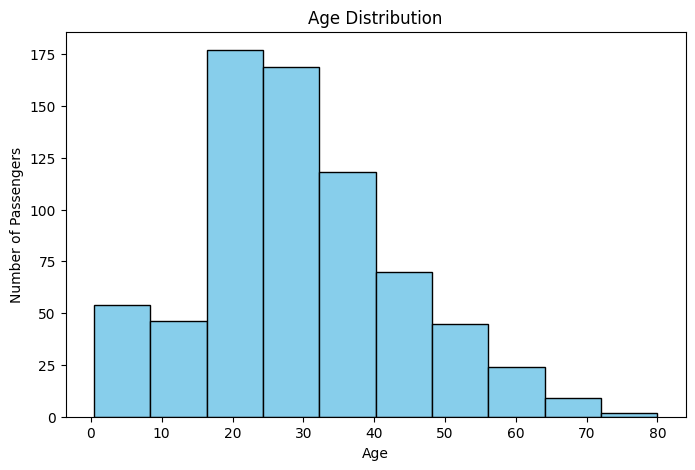

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(train['Age'], bins=10, edgecolor='black', color="skyblue")
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

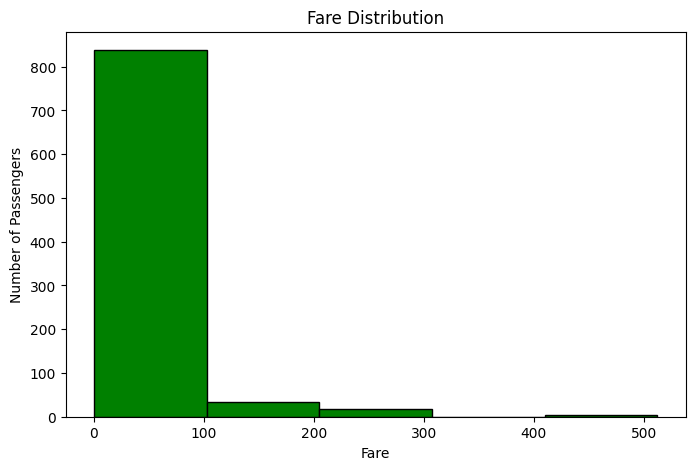

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(train['Fare'], bins=5, edgecolor='black', color="green")
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.show()

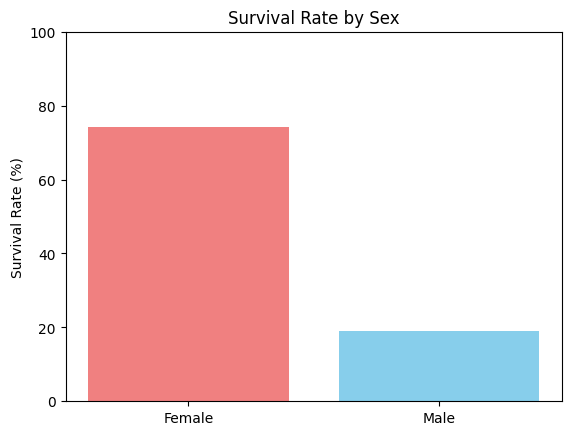

In [ ]:
sex_survival_rates = [female_survival_rate, male_survival_rate]
labels = ['Female', 'Male']

plt.bar(labels, sex_survival_rates, color=['lightcoral', 'skyblue'])
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)

plt.show()

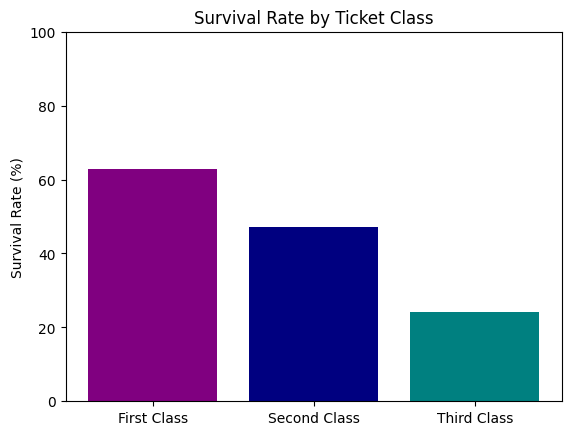

In [ ]:
pclass_survival_rates = [first_class_survival_rate, second_class_survival_rate, third_class_survival_rate]
labels = ['First Class', 'Second Class', 'Third Class']

plt.bar(labels, pclass_survival_rates, color=['purple', 'navy', 'teal'])
plt.title('Survival Rate by Ticket Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)

plt.show()

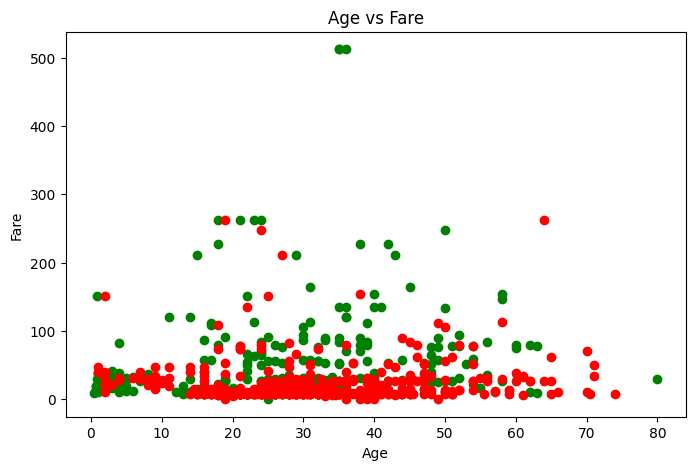

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(train['Age'][train['Survived']==1], train['Fare'][train['Survived']==1], color='green', label='Survived')
plt.scatter(train['Age'][train['Survived']==0], train['Fare'][train['Survived']==0], color='red', label='Did not survive')

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

In [ ]:
!pip install openai

In [ ]:
from openai import OpenAI

In [ ]:
train2 = pd.read_csv("train.csv")

In [ ]:
grouped = train2.groupby(['Sex', 'Pclass']).agg(
    Avg_Age=('Age', 'mean'),
    Avg_Fare=('Fare', 'mean'),
    Survival_Rate=('Survived', 'mean')
).reset_index()

grouped = grouped.round({'Avg_Age': 1, 'Avg_Fare': 1, 'Survival_Rate': 2})

In [ ]:
table_str = grouped.to_markdown(index=False)

In [ ]:
##PLACE API KEY##
client = OpenAI(api_key="")

In [ ]:
def generate_report():
    prompt = f"""
    You are a data analyst. Below is a summary table of Titanic passengers:

    {table_str}

    Write a concise natural-language report that includes:
    - Which passenger group had the highest survival rate?
    - Are there any unusual patterns in fare vs age?
    - Suggest a new feature or visualization to explore survival trends.
    - Summarize which factors most influenced survival.
    - Explain why children might have had higher survival rates than adults.
    - Suggest one feature I could create that might improve insights about survival
    - Which groups should we plot together to detect hidden trends in survival?
    - Who paid the highest fare and did they survive?

    The report should read like a short findings summary for stakeholders.
    """
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

In [ ]:
print(generate_report())

### Findings Summary on Titanic Passenger Survival

The analysis of Titanic passenger data reveals key insights regarding survival rates across different groups:

1. **Highest Survival Rate**: Female passengers from first class (Pclass 1) had the highest survival rate at 97%, significantly outpacing other groups, particularly males in third class, who had a survival rate of only 14%.

2. **Unusual Patterns in Fare vs Age**: Notably, as the average age of passengers decreases, the average fare typically decreases as well, particularly when comparing first-class female passengers (avg age 34.6, avg fare 106.1) to third-class ones (avg age 21.8, avg fare 16.1). This suggests that younger passengers tend to occupy lower fare brackets, while older passengers, often with more resources, purchased higher fare tickets.

3. **Suggested Feature or Visualization**: To further explore survival trends, implementing a visual representation of survival rates segmented by both age and class would be v